<a href="https://colab.research.google.com/github/rashminiyashodha7/smartfactory-predictive-maintenance-system/blob/main/Smart_Factory_Predictive_Maintenance_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install xgboost

In [2]:
# Download the dataset
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv

--2026-04-22 19:12:57--  https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘ai4i2020.csv’

ai4i2020.csv            [ <=>                ] 509.81K  --.-KB/s    in 0.1s    

2026-04-22 19:12:58 (3.64 MB/s) - ‘ai4i2020.csv’ saved [522048]



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Assuming the dataset is downloaded as 'ai4i2020.csv'
df = pd.read_csv('ai4i2020.csv')
print(df.head())
print(df.info())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

In [6]:
# Check for missing values
print(df.isnull().sum())

# Encode categorical variables (e.g., 'Type' column)
le = LabelEncoder()
df['Type'] = le.fit_transform(df['Type'])

# Separate features and target (binary: predict 'Machine failure')
X = df.drop(['Machine failure', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1)
y = df['Machine failure']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


               UDI         Type  Air temperature [K]  Process temperature [K]  \
count  10000.00000  10000.00000         10000.000000             10000.000000   
mean    5000.50000      1.19940           300.004930               310.005560   
std     2886.89568      0.60023             2.000259                 1.483734   
min        1.00000      0.00000           295.300000               305.700000   
25%     2500.75000      1.00000           298.300000               308.800000   
50%     5000.50000      1.00000           300.100000               310.100000   
75%     7500.25000      2.00000           301.500000               311.100000   
max    10000.00000      2.00000           304.500000               313.800000   

       Rotational speed [rpm]   Torque [Nm]  Tool wear [min]  Machine failure  \
count            10000.000000  10000.000000     10000.000000     10000.000000   
mean              1538.776100     39.986910       107.951000         0.033900   
std                179.2840

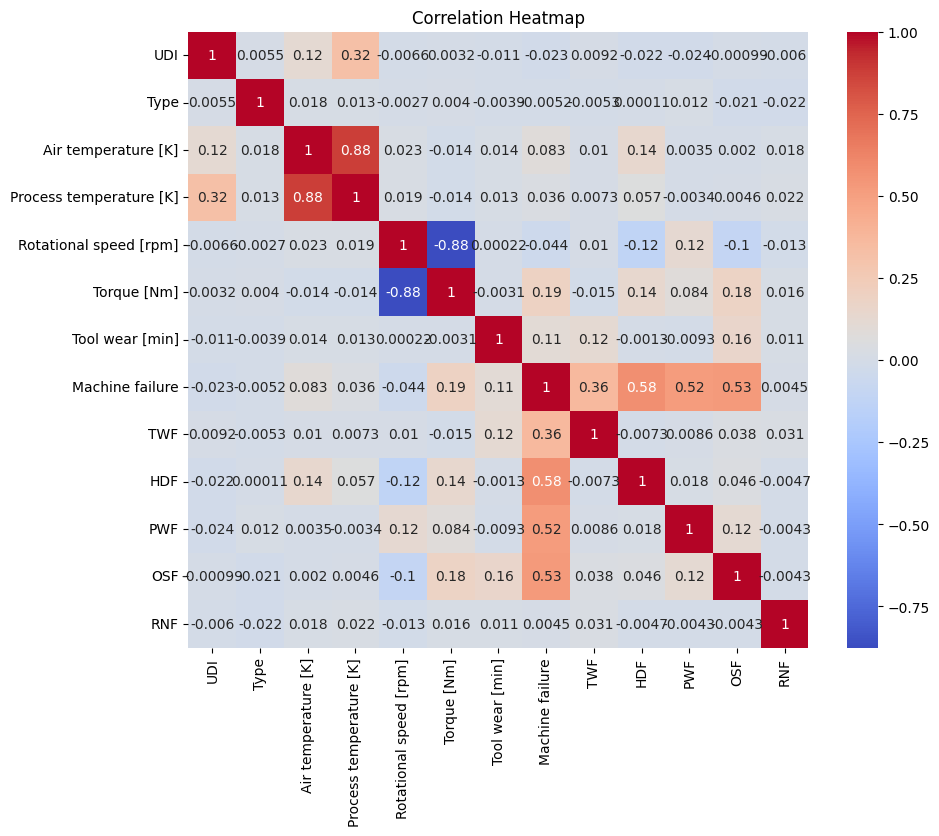

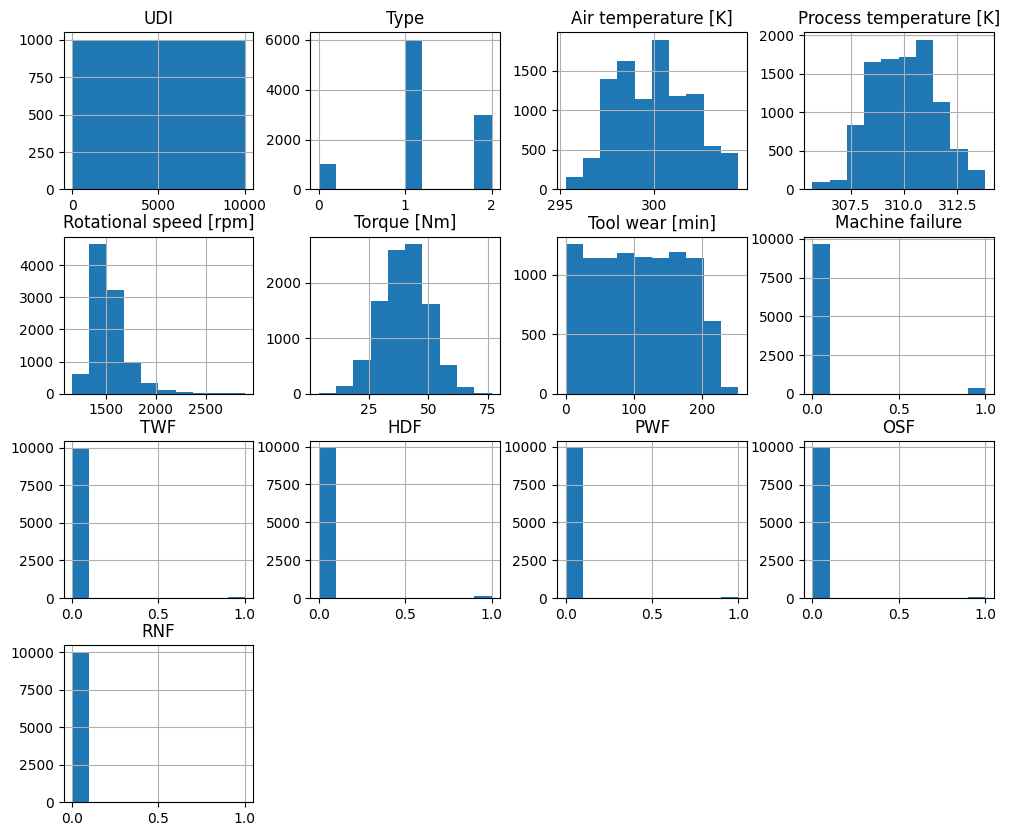

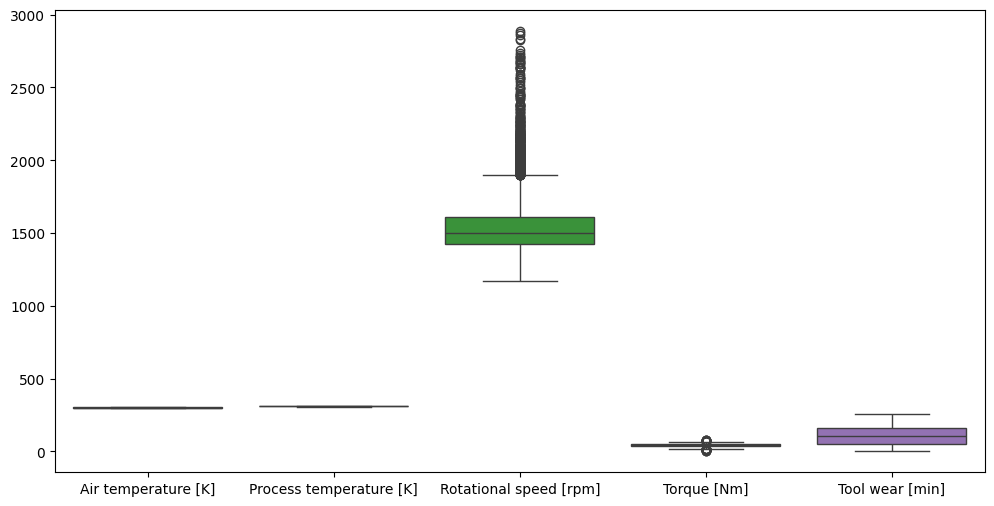

In [8]:
# Summary statistics
print(df.describe())

# Check class distribution
print(y.value_counts())

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Distribution of features
df.hist(figsize=(12,10))
plt.show()

# Box plots for outliers
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']])
plt.show()

In [11]:
# Add new feature: Power consumption = Torque * Rotational speed
df['Power'] = df['Torque [Nm]'] * df['Rotational speed [rpm]']

# Update X and re-split
X = df.drop(['Machine failure', 'Product ID', 'UDI', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# Model 1: Logistic Regression
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

# Model 3: XGBoost
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)

Logistic Regression:
Accuracy: 0.973
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1939
           1       0.64      0.26      0.37        61

    accuracy                           0.97      2000
   macro avg       0.81      0.63      0.68      2000
weighted avg       0.97      0.97      0.97      2000



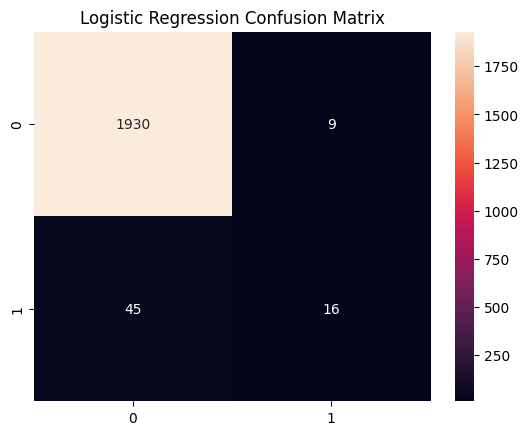

Random Forest:
Accuracy: 0.9875
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1939
           1       0.95      0.62      0.75        61

    accuracy                           0.99      2000
   macro avg       0.97      0.81      0.87      2000
weighted avg       0.99      0.99      0.99      2000



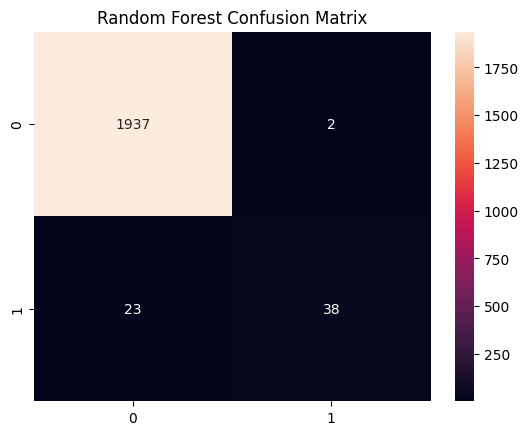

XGBoost:
Accuracy: 0.988
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1939
           1       0.89      0.69      0.78        61

    accuracy                           0.99      2000
   macro avg       0.94      0.84      0.89      2000
weighted avg       0.99      0.99      0.99      2000



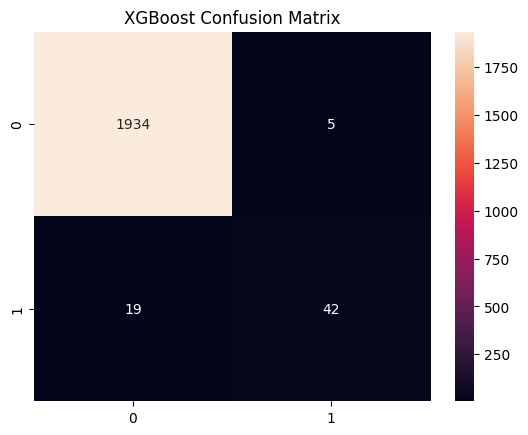

In [13]:
# Evaluate Logistic Regression
print('Logistic Regression:')
print('Accuracy:', accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

# Evaluate Random Forest
print('Random Forest:')
print('Accuracy:', accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title('Random Forest Confusion Matrix')
plt.show()

# Evaluate XGBoost
print('XGBoost:')
print('Accuracy:', accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d')
plt.title('XGBoost Confusion Matrix')
plt.show()